In [1]:
# Install (if needed)
!pip install -q datasets tensorflow scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import classification_report

In [3]:
ds = load_dataset("fancyzhx/ag_news")

train_data = ds["train"]
test_data = ds["test"]

print(train_data[0])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

c:\Users\AB\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AB\.cache\huggingface\hub\datasets--fancyzhx--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [4]:
X_train = train_data["text"]
y_train = np.array(train_data["label"])

X_test = test_data["text"]
y_test = np.array(test_data["label"])

In [5]:
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [6]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(64, activation="relu"),
    Dense(4, activation="softmax")
])

model.summary()

c:\Users\AB\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6086 - loss: 0.9959 - val_accuracy: 0.6821 - val_loss: 0.8979
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6364 - loss: 0.9524 - val_accuracy: 0.6571 - val_loss: 0.9437
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.7087 - loss: 0.8034 - val_accuracy: 0.6543 - val_loss: 0.9205
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.6515 - loss: 0.8870 - val_accuracy: 0.6189 - val_loss: 0.9826
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6304 - loss: 0.9368 - val_accuracy: 0.4582 - val_loss: 1.2057


In [9]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4503 - loss: 1.2101
Test Accuracy: 0.4502631723880768


In [10]:
pred = model.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_labels))

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.40      0.46      0.43      1900
           1       0.47      0.66      0.55      1900
           2       0.46      0.46      0.46      1900
           3       0.50      0.23      0.31      1900

    accuracy                           0.45      7600
   macro avg       0.46      0.45      0.44      7600
weighted avg       0.46      0.45      0.44      7600



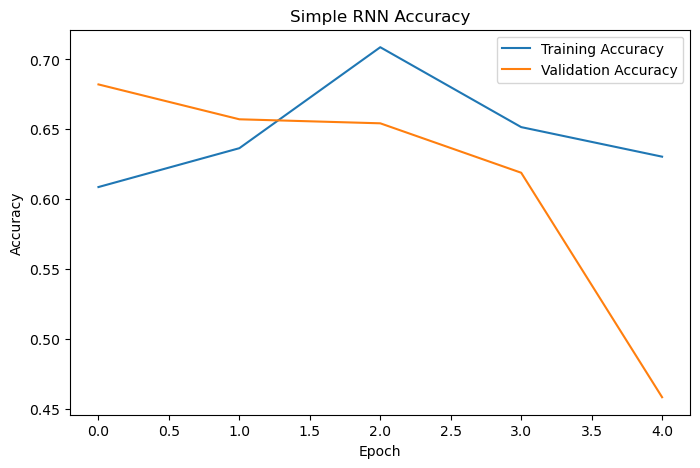

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Simple RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

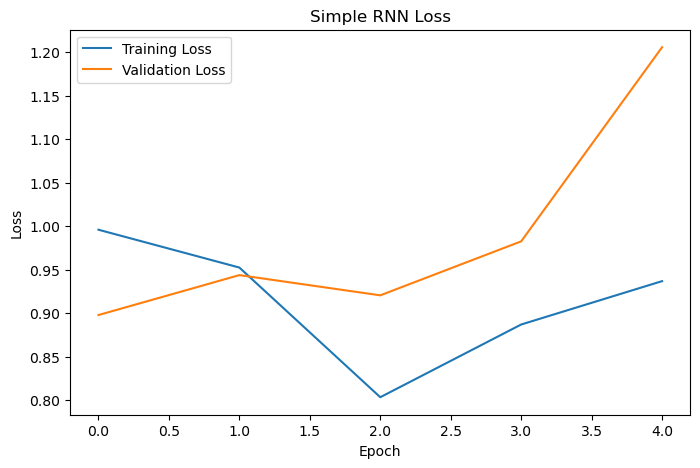

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Simple RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
labels = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

news = [
    "India defeated Australia in the cricket final.",
    "Apple launches a new AI-powered iPhone.",
    "NASA discovers a new planet.",
    "Stock market reaches a record high."
]

seq = tokenizer.texts_to_sequences(news)
pad = pad_sequences(seq, maxlen=max_length, padding="post")

pred = model.predict(pad)

for text, p in zip(news, pred):
    print("News:", text)
    print("Category:", labels[np.argmax(p)])
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
News: India defeated Australia in the cricket final.
Category: Sports

News: Apple launches a new AI-powered iPhone.
Category: Business

News: NASA discovers a new planet.
Category: Business

News: Stock market reaches a record high.
Category: Sci/Tech

